#| label: lab1_intro

# Machine Learning 1 - Nearest Neighbors and Decision Trees

## Lab objectives

* Classification with decision trees and random forests.
* Cross-validation and evaluation.

In [7]:
from lab_tools import CIFAR10, get_hog_image

dataset = CIFAR10('/Users/alice/Desktop/INFO-H501 - Pattern/CIFAR10')

Pre-loading training data
Pre-loading test data


# 1. Nearest Neighbor

The following example uses the Nearest Neighbor algorithm on the Histogram of Gradient decriptors in the dataset.

In [8]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit( dataset.train['hog'], dataset.train['labels'] )

KNeighborsClassifier(n_neighbors=1)

* What is the **descriptive performance** of this classifier ?
* Modify the code to estimate the **predictive performance**.
* Use cross-validation to find the best hyper-parameters for this method.

Train accuracy:  1.0


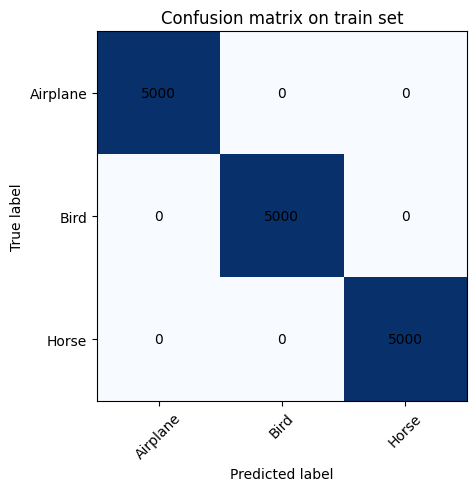

In [9]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

print("Train accuracy: ", clf.score( dataset.train['hog'], dataset.train['labels'] ))

#confusion matrix on train set
cm = confusion_matrix(dataset.train['labels'], clf.predict(dataset.train['hog']))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion matrix on train set')
plt.xticks(range(3), dataset.labels, rotation=45)
plt.yticks(range(3), dataset.labels)
plt.ylabel('True label')
plt.xlabel('Predicted label')

# Write the numbers directly into the cases
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='black')

plt.show()

Descriptive accuracy (k=1): 1.0000
k=  1: 0.6878 +- 0.0072
k=  3: 0.7061 +- 0.0076
k=  5: 0.7097 +- 0.0074
k=  7: 0.7079 +- 0.0045
k= 11: 0.7039 +- 0.0079
k= 15: 0.7009 +- 0.0089
k= 21: 0.6933 +- 0.0070


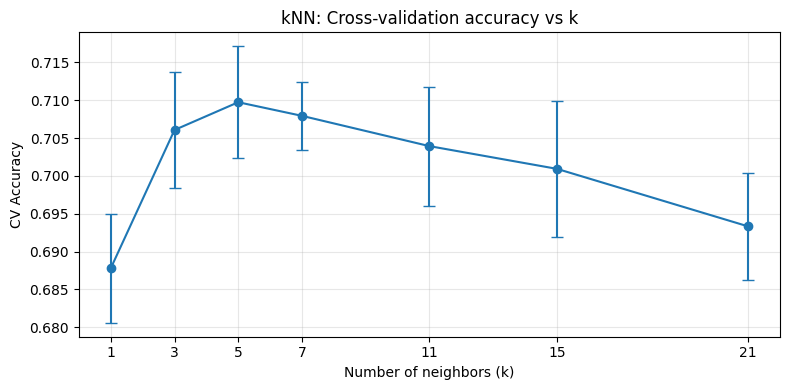


Best k: 5


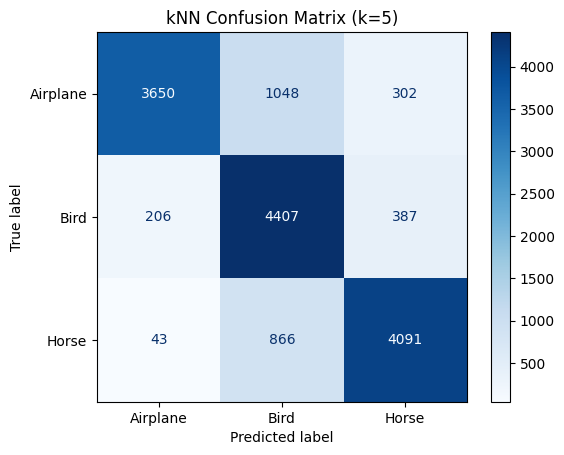

              precision    recall  f1-score   support

    Airplane       0.89      0.62      0.73      1000
        Bird       0.60      0.81      0.69      1000
       Horse       0.77      0.74      0.75      1000

    accuracy                           0.72      3000
   macro avg       0.75      0.72      0.72      3000
weighted avg       0.75      0.72      0.72      3000



In [10]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import numpy as np
import matplotlib.pyplot as plt

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(dataset.train['hog'], dataset.train['labels'])
train_acc = clf.score(dataset.train['hog'], dataset.train['labels'])
print(f"Descriptive accuracy (k=1): {train_acc:.4f}") # k=1 means every point is its own nearest neighbor

k_values = [1, 3, 5, 7, 11, 15, 21]
cv_means, cv_stds = [], []

for k in k_values:
    clf = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(clf, dataset.train['hog'], dataset.train['labels'], cv=5)
    cv_means.append(scores.mean())
    cv_stds.append(scores.std())
    print(f"k={k:3d}: {scores.mean():.4f} +- {scores.std():.4f}")

plt.figure(figsize=(8, 4))
plt.errorbar(k_values, cv_means, yerr=cv_stds, fmt='-o', capsize=4)
plt.xlabel("Number of neighbors (k)")
plt.ylabel("CV Accuracy")
plt.title("kNN: Cross-validation accuracy vs k")
plt.xticks(k_values)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("knn_cv.png", dpi=150)
plt.show()

best_k = k_values[np.argmax(cv_means)]
print(f"\nBest k: {best_k}")

clf_best = KNeighborsClassifier(n_neighbors=best_k)
clf_best.fit(dataset.train['hog'], dataset.train['labels'])
y_pred = clf_best.predict(dataset.train['hog'])

cm = confusion_matrix(dataset.train['labels'], y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=dataset.labels)
disp.plot(cmap='Blues')
plt.title(f"kNN Confusion Matrix (k={best_k})")
plt.savefig("knn_cm.png", dpi=150)
plt.show()

print(classification_report( dataset.test['labels'], clf_best.predict( dataset.test['hog'] ), target_names=dataset.labels ) )

## 2. Decision Trees

[Decision Trees](http://scikit-learn.org/stable/modules/tree.html#tree) classify the data by splitting the feature space according to simple, single-feature rules. Scikit-learn uses the [CART](https://en.wikipedia.org/wiki/Predictive_analytics#Classification_and_regression_trees_.28CART.29) algorithm for [its implementation](http://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) of the classifier. 

* **Create a simple Decision Tree classifier** using scikit-learn and train it on the HoG training set.
* Use cross-validation to find the best hyper-paramters for this method.

max_depth=   2: 0.4807 +- 0.0027
max_depth=   4: 0.5532 +- 0.0122
max_depth=   6: 0.5830 +- 0.0061
max_depth=   8: 0.5970 +- 0.0043
max_depth=  10: 0.5973 +- 0.0068
max_depth=  15: 0.5868 +- 0.0082
max_depth=  20: 0.5828 +- 0.0053
max_depth=None: 0.5766 +- 0.0068


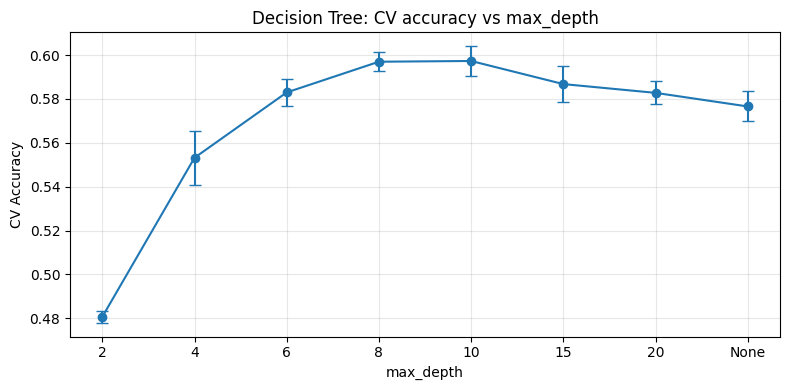


Best max_depth: 10
p-value (best vs unlimited): 0.003594


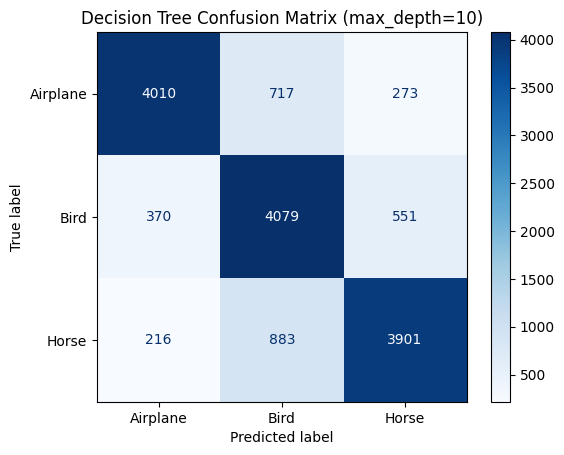

In [11]:
from sklearn.tree import DecisionTreeClassifier
from scipy.stats import ttest_rel

depths = [2, 4, 6, 8, 10, 15, 20, None]
cv_means_dt, cv_stds_dt = [], []

for d in depths: 
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf, dataset.train['hog'], dataset.train['labels'], cv=5)
    cv_means_dt.append(scores.mean())
    cv_stds_dt.append(scores.std())
    label = str(d) if d is not None else "None"
    print(f"max_depth={label:>4}: {scores.mean():.4f} +- {scores.std():.4f}")

depth_labels = [str(d) if d is not None else "None" for d in depths]
plt.figure(figsize=(8,4))
plt.errorbar(range(len(depths)), cv_means_dt, yerr=cv_stds_dt, fmt='-o', capsize=4)
plt.xticks(range(len(depths)), depth_labels)
plt.xlabel("max_depth")
plt.ylabel("CV Accuracy")
plt.title("Decision Tree: CV accuracy vs max_depth")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("dt_cv.png", dpi=150)
plt.show()

best_depth = depths[np.argmax(cv_means_dt)]
print(f"\nBest max_depth: {best_depth}")

scores_best = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=42), dataset.train['hog'], dataset.train['labels'], cv=5)
scores_unlimited = cross_val_score(DecisionTreeClassifier(max_depth=None, random_state=42), dataset.train['hog'], dataset.train['labels'], cv=5)

t, p = ttest_rel(scores_best, scores_unlimited)
print(f"p-value (best vs unlimited): {p:.6f}")

clf_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
clf_dt.fit(dataset.train['hog'], dataset.train['labels'])
y_pred_dt = clf_dt.predict(dataset.train['hog'])
cm_dt = confusion_matrix(dataset.train['labels'], y_pred_dt)
disp = ConfusionMatrixDisplay(cm_dt, display_labels=dataset.labels)
disp.plot(cmap='Blues')
plt.title(f"Decision Tree Confusion Matrix (max_depth={best_depth})")
plt.savefig("dt_cm.png", dpi=150)
plt.show()

## 3. Random Forests

[Random Forest](http://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) classifiers use multiple decision trees trained on "weaker" datasets (less data and/or less features), averaging the results so as to reduce over-fitting.

* Use scikit-learn to **create a Random Forest classifier** on the CIFAR data. 
* Use cross-validation to find the best hyper-paramters for this method.

n_estimators=  10: 0.6701 +- 0.0049
n_estimators=  25: 0.7231 +- 0.0024
n_estimators=  50: 0.7454 +- 0.0033
n_estimators= 100: 0.7578 +- 0.0040
n_estimators= 200: 0.7651 +- 0.0020


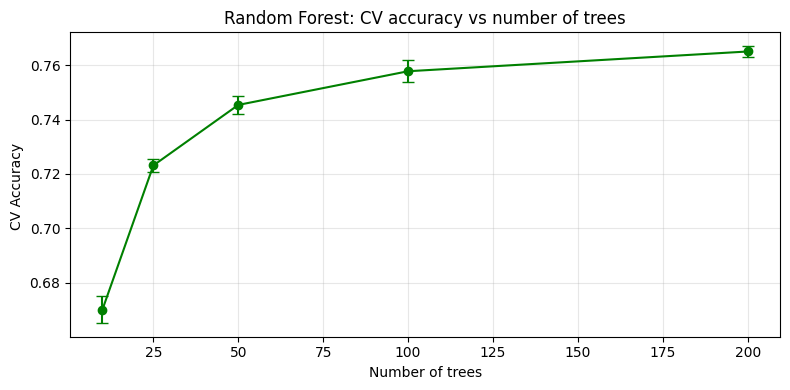

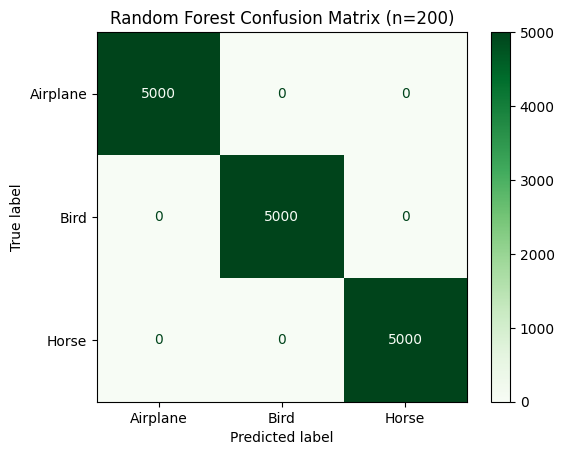

In [12]:
from sklearn.ensemble import RandomForestClassifier

n_trees = [10, 25, 50, 100, 200]
cv_means_rf, cv_stds_rf = [], []

for n in n_trees:
    clf = RandomForestClassifier(n_estimators=n, random_state=42)
    scores = cross_val_score(clf, dataset.train['hog'], dataset.train['labels'], cv = 5)
    cv_means_rf.append(scores.mean())
    cv_stds_rf.append(scores.std())
    print(f"n_estimators={n:4d}: {scores.mean():.4f} +- {scores.std():.4f}")

plt.figure(figsize=(8,4))
plt.errorbar(n_trees, cv_means_rf, yerr=cv_stds_rf, fmt = '-o', capsize=4, color='green')
plt.xlabel("Number of trees")
plt.ylabel("CV Accuracy ")
plt.title("Random Forest: CV accuracy vs number of trees")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("rf_cv.png", dpi=150)
plt.show()

best_n = n_trees[np.argmax(cv_means_rf)]
clf_rf = RandomForestClassifier(n_estimators=best_n, random_state=42)
clf_rf.fit(dataset.train['hog'], dataset.train['labels'])
y_pred_rf = clf_rf.predict(dataset.train['hog'])
cm_rf = confusion_matrix(dataset.train['labels'], y_pred_rf)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=dataset.labels)
disp.plot(cmap='Greens')
plt.title(f"Random Forest Confusion Matrix (n={best_n})")
plt.savefig("rf_cm.png", dpi=150)
plt.show()


Comparaison of all 3 methods

In [13]:
from scipy.stats import ttest_rel
from sklearn.linear_model import RidgeClassifier

scores_knn = cross_val_score(KNeighborsClassifier(n_neighbors=best_k), dataset.train['hog'], dataset.train['labels'], cv=5)
scores_dt = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=42), dataset.train['hog'], dataset.train['labels'], cv=5)
scores_rf = cross_val_score(RandomForestClassifier(n_estimators=best_depth, random_state=42), dataset.train['hog'], dataset.train['labels'], cv=5)

scores_ridge = cross_val_score(RidgeClassifier(alpha=0.1),
                                dataset.train['hog'], dataset.train['labels'], cv=5)

print("Method         | Mean   | Std")
print("---------------|--------|-------")
print(f"Ridge (Lab 0)  | {scores_ridge.mean():.4f} | {scores_ridge.std():.4f}")
print(f"kNN (k={best_k})      | {scores_knn.mean():.4f} | {scores_knn.std():.4f}")
print(f"Decision Tree  | {scores_dt.mean():.4f} | {scores_dt.std():.4f}")
print(f"Random Forest  | {scores_rf.mean():.4f} | {scores_rf.std():.4f}")

for name, scores in [("kNN", scores_knn), ("DT", scores_dt), ("RF", scores_rf)]:
    t, p = ttest_rel(scores, scores_ridge)
    print(f"{name} vs Ridge: p={p:.6f} ({'significant' if p < 0.05 else 'not significant'})")

Method         | Mean   | Std
---------------|--------|-------
Ridge (Lab 0)  | 0.7443 | 0.0084
kNN (k=5)      | 0.7097 | 0.0074
Decision Tree  | 0.5973 | 0.0068
Random Forest  | 0.6701 | 0.0049
kNN vs Ridge: p=0.000016 (significant)
DT vs Ridge: p=0.000018 (significant)
RF vs Ridge: p=0.000160 (significant)
